# 1.0 import libraries


In [3]:
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve)
tf.random.set_seed(42)
np.random.seed(42)


In [4]:
train_df=pd.read_csv('diabetes_train.csv')
val_df=pd.read_csv('diabetes_val.csv')
test_df=pd.read_csv('diabetes_test.csv')

X_train=train_df.drop(columns=['Outcome']).values.astype(np.float32)
y_train = train_df['Outcome'].values.astype(np.float32)

X_val=val_df.drop(columns=['Outcome']).values.astype(np.float32)
y_val=val_df['Outcome'].values.astype(np.float32)

X_test=test_df.drop(columns=['Outcome']).values.astype(np.float32)
y_test=test_df['Outcome'].values.astype(np.float32)

print(f"Train: {X_train.shape}")
print(f"Val: {X_val.shape}")
print(f"Test: {X_test.shape}")
print(f"num of features: {X_train.shape[1]}")

Train: (537, 14)
Val: (115, 14)
Test: (116, 14)
num of features: 14


In [5]:
with open ('diabetes_metadata.json') as f :
    metadata = json.load(f)
feature_cols = metadata['feature_cols']
train_medians= metadata['train_medians']
scaler_mean= np.array(metadata['scaler_mean'], dtype=np.float32)
scaler_scale = np.array(metadata['scaler_scale'], dtype=np.float32)

print(f"loaded metadata for {len(feature_cols)} features")

scaler_scale



loaded metadata for 14 features


array([3.3820171e+00, 2.9510159e+01, 1.2327506e+01, 9.1778965e+00,
       8.1450020e+01, 6.6842527e+00, 3.2427591e-01, 1.1811565e+01,
       1.3876493e+03, 4.3319400e+02, 4.3056646e-01, 4.8798811e-01,
       4.8535880e-01, 4.5137453e-01], dtype=float32)

In [6]:
def build_ann(n_features):
    inputs = keras.Input(shape=(n_features,), name='features')

    #block1
    x=keras.layers.Dense(128, kernel_regularizer=keras.regularizers.l2(1e-4))(inputs)
    x=keras.layers.BatchNormalization()(x)
    x=keras.layers.Activation('relu')(x)
    x=keras.layers.Dropout(0.3)(x)


    #block 2
    x=keras.layers.Dense(64, kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x=keras.layers.BatchNormalization()(x)
    x=keras.layers.Activation('relu')(x)
    x=keras.layers.Dropout(0.3)(x)

     #block 3
    x=keras.layers.Dense(32)(x)
    x=keras.layers.Activation('relu')(x)
    x=keras.layers.Dropout(0.2)(x)

    outputs = keras.layers.Dense(1, activation='sigmoid', name='prob')(x)

    return keras.Model(inputs, outputs, name='DiabetesANN')
    
model = build_ann(X_train.shape[1])
model.summary()



Model: "DiabetesANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ features (InputLayer)                │ (None, 14)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │           1,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ prob (Dense)                         │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,057 (51.00 KB)

 Trainable params: 12,673 (49.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [7]:
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=5e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
    ]
)
                          


In [8]:
callbacks=[
    keras.callbacks.EarlyStopping(
        monitor='val_auc', patience=25,
        restore_best_weights=True, mode='max', verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc', factor=0.5, patience=10,
        min_lr=1e-6, mode='max', verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        'best_diabetes.keras', monitor='val_auc',
        save_best_only=True, mode='max', verbose=0
    ),
]

history = model.fit(
    X_train, y_train, epochs=300, batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1,
)

print(f"\nEpochs run:  {len(history.history['loss'])}")
print(f"Best val AUC:  {max(history.history['val_auc']):.4f}")


Epoch 1/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - accuracy: 0.4264 - auc: 0.5046 - loss: 0.8754 - precision: 0.3438 - recall: 0.7021 - val_accuracy: 0.5739 - val_auc: 0.7533 - val_loss: 0.6907 - val_precision: 0.4444 - val_recall: 0.9000 - learning_rate: 5.0000e-04
Epoch 2/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6108 - auc: 0.6608 - loss: 0.6953 - precision: 0.4588 - recall: 0.6223 - val_accuracy: 0.7304 - val_auc: 0.7942 - val_loss: 0.6368 - val_precision: 0.6047 - val_recall: 0.6500 - learning_rate: 5.0000e-04
Epoch 3/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6983 - auc: 0.7327 - loss: 0.5964 - precision: 0.5670 - recall: 0.5851 - val_accuracy: 0.7652 - val_auc: 0.8117 - val_loss: 0.5942 - val_precision: 0.6667 - val_recall: 0.6500 - learning_rate: 5.0000e-04
Epoch 4/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7672 - auc: 0.7995 - loss: 0.5414 - precision: 0.6957 - recall: 0.5957 - val_accuracy: 0.7565 - val_auc: 0.8212 - val_loss: 

<function matplotlib.pyplot.show(close=None, block=None)>

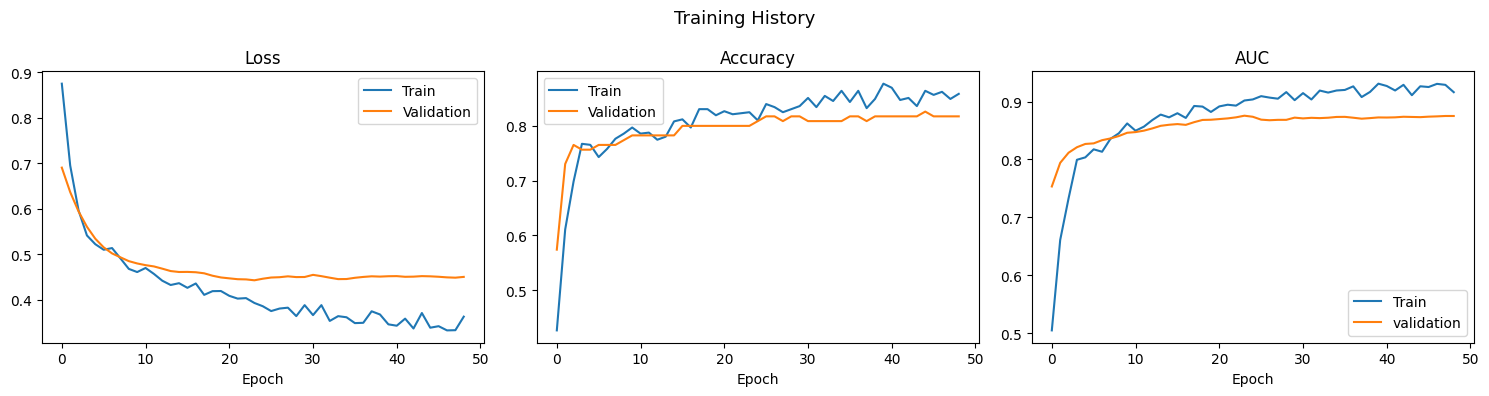

In [9]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history.history['auc'], label='Train')
axes[2].plot(history.history['val_auc'], label='validation')
axes[2].set_xlabel('Epoch')
axes[2].set_title('AUC')
axes[2].legend()

plt.suptitle('Training History', fontsize=13)
plt.tight_layout()
plt.savefig('training_history.png' , dpi=150, bbox_inches='tight')
plt.show

In [10]:
model.load_weights('best_diabetes.keras')
test_results=model.evaluate(X_test, y_test, verbose=0)
for name, value in zip(model.metrics_names, test_results):
    print (f"{name:<12}: {value:.4f}")

loss        : 0.4353
compile_metrics: 0.7845


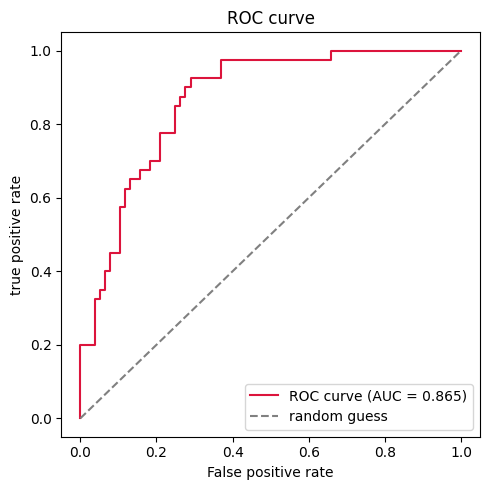

ROC-AUC : 0.8655


In [12]:
y_prob = model.predict(X_test, verbose=0).flatten()
auc_score = roc_auc_score(y_test, y_prob)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize = (5,5))
plt.plot(fpr,tpr, color='crimson', label=f"ROC curve (AUC = {auc_score:.3f})")
plt.plot([0,1], [0,1], color = 'gray', linestyle='--', label='random guess')
plt.xlabel("False positive rate")
plt.ylabel("true positive rate")
plt.title("ROC curve")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"ROC-AUC : {auc_score:.4f}")